# Bell state 01+10 con Qiskit

## 0. Instalación


In [1]:
!pip -q install qiskit qiskit-aer matplotlib pylatexenc



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Importamos lo que vamos a usar

Qiskit, el simulador de Aer y algunas herramientas para medir

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error,
    thermal_relaxation_error,
    ReadoutError,
)
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram


Estado objetivo |psi>:
[0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]


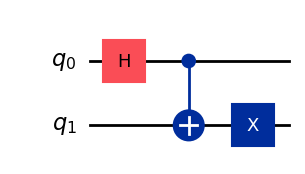

In [3]:
shots = 4096

# Circuito pequeñito solo para preparar el estado final teorico
prep = QuantumCircuit(2)
prep.h(0)
prep.cx(0, 1)
prep.x(1)

# Guardamos el estado objetivo 
target_state = Statevector.from_instruction(prep)
target_dm = DensityMatrix(target_state)

print("Estado objetivo |psi>:")
print(np.round(target_state.data, 4))
prep.draw("mpl")

## 3. El circuito de Bell 01+10

Tenemos 2 qubits:

- `q0`: el qubit que vamos a medir
- `q1`: qubit auxiliar


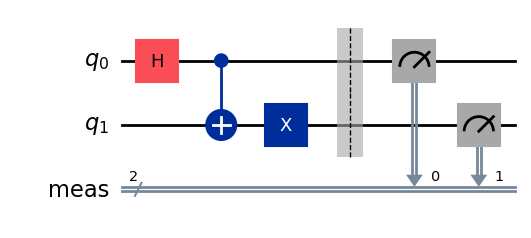

In [4]:
def bell_psi_plus(save_dm=True):
    """Circuito de Bell sin medidas intermedias

    Es ideal para calcular la fidelidad usando matrices de densidad

    Solo lo utilizamos para eso, para comprobar :)
    """
    qc = QuantumCircuit(2, name="bell_psi_plus")

    # 1) Poner qubit 0 en superposición
    qc.h(0)

    # 2) Interferencia y medición
   
    qc.cx(0,1)
    qc.x(1) #flip second qubit
    

    # Guardamos la matriz de densidad final 
    if save_dm:
        qc.save_density_matrix()

    return qc


def bell_psi_plus_success_circuit():
    """Circuito para comprobar el éxito con mediciones

    Truco: si Bob tiene de verdad |psi>, deshacemos la preparación en q2
    con el circuito de preparación estado inverso y entonces Bob debería medir
    0 casi siempre ;)
    """
    qc = bell_psi_plus(save_dm=False)
    qc.measure_all()
    
   # qc.measure(0,0)

    return qc


qc_dm = bell_psi_plus()
qc_meas = bell_psi_plus_success_circuit()

qc_meas.draw("mpl")


## 4. Dos formas de comprobar si funcionó

Vamos a mirar dos cosas:

1. **Fidelidad**: número entre 0 y 1 que dice qué tan parecido es el qubit 0 al estado original. Si vale 1, perfecto.
2. **Probabilidad de éxito en medición**: deshacemos la preparación en q0 y medimos. Si todo fue bien, q0 debería salir en `0`.

**Fíjate en el argumento noise_model, ahí es donde metemos luego el tipo y cantidad de ruido**


In [5]:

def bell_fidelity(noise_model=None, optimization_level=0):
    """Fidelidad entre el estado Bell completo y el estado objetivo."""
    backend = AerSimulator(method="density_matrix", noise_model=noise_model)
    tqc = transpile(qc_dm, backend, optimization_level=optimization_level)
    result = backend.run(tqc, shots=1).result()

    rho_total = DensityMatrix(result.data(0)["density_matrix"])

    # Compare FULL 2-qubit state (no partial trace!)
    return float(np.real(state_fidelity(rho_total, target_dm)))



def bell_success_counts(noise_model=None, shots=4096, optimization_level=0):
    """Devuelve los conteos y la probabilidad de que q0 mida 0."""
    backend = AerSimulator(noise_model=noise_model)
    tqc = transpile(qc_meas, backend, optimization_level=optimization_level)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    # En las claves tipo '010', el bit de q2 aparece a la izquierda.
    #p_bob_0 = sum(
       # v for bitstring, v in counts.items()
       # if bitstring.replace(" ", "")[0] == "0"
    #) / shots

    #salida correlacionada

    success_counts = counts.get('01', 0) + counts.get('10', 0)
    p_success = success_counts / shots

    return counts, p_success


## 5. Ahora sí: metemos ruido

Un `NoiseModel` le dice al simulador: "cada vez que aparezca tal puerta, ponle este error"

Vamos a probar varios ruidos típicos:

- **Despolarizante**: como si el qubit se volviera un poco aleatorio
- **Amortiguamiento de amplitud**: simula que el qubit tiende a relajarse hacia $|0\rangle$. Los qubits reales tienen este problema
- **Amortiguamiento de fase**: se deteriora solo la fase
- **Relajación térmica $T_1/T_2$**: una versión más física de decoherencia (pasa de este de momento, que es más complicado, pero la idea es que cuanto más tiempo dure la cosa, más se fastidia todo)
- **Error de lectura**: el qubit está bien, pero el aparato lo lee mal

Las tasas están puestas bastante visibles para que se note en las gráficas


In [6]:
one_qubit_gates = ["h", "x", "sx", "rx", "ry", "rz"]
two_qubit_gates = ["cx", "cz"]


def depolarizing_noise(p1=0.003, p2=0.03):
    """Ruido que mezcla el estado con algo aleatorio"""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), one_qubit_gates)
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), two_qubit_gates)
    return nm


def amplitude_damping_noise(gamma=0.02):
    """Ruido tipo relajación: el qubit tiende a caer hacia |0>"""
    nm = NoiseModel()
    e1 = amplitude_damping_error(gamma)
    e2 = e1.tensor(e1)
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def phase_damping_noise(lam=0.03):
    """Ruido que borra fase: fastidia superposiciones sin cambiar tanto poblaciones"""
    nm = NoiseModel()
    e1 = phase_damping_error(lam)
    e2 = e1.tensor(e1)
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def thermal_relaxation_noise(t1=50e3, t2=70e3, gate_time_1q=50, gate_time_2q=300):
    """Ruido más físico basado en T1 y T2

    Importante: las unidades deben ser consistentes.
    Aquí usamos ns para T1/T2 y para tiempos de puerta.
    Además, Qiskit pide que T2 <= 2*T1.
    """
    nm = NoiseModel()
    e1 = thermal_relaxation_error(t1, t2, gate_time_1q)
    e2 = thermal_relaxation_error(t1, t2, gate_time_2q).tensor(
        thermal_relaxation_error(t1, t2, gate_time_2q)
    )
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def readout_noise(p01=0.03, p10=0.06):
    """Error de lectura.

    p01: el qubit era 0, pero lo leemos como 1.
    p10: el qubit era 1, pero lo leemos como 0.
    """
    nm = NoiseModel()
    ro = ReadoutError([[1 - p01, p01], [p10, 1 - p10]])
    nm.add_all_qubit_readout_error(ro)
    return nm


noise_models = {
    "ideal / sin ruido": None,
    "despolarizante": depolarizing_noise(p1=0.002, p2=0.01),
    #"despolarizante Qmio": depolarizing_noise(p1=0.02, p2=0.05),
    "amortiguamiento de amplitud": amplitude_damping_noise(gamma=0.01),
    #"amortiguamiento de amplitud Qimio": amplitude_damping_noise(gamma=0.15),
    "amortiguamiento de fase": phase_damping_noise(lam=0.01),
    #"amortiguamiento de fase Qmio": phase_damping_noise(lam=0.05),
    "relajación térmica T1/T2": thermal_relaxation_noise(
        t1=50e3,
        #t1=50e3,
        t2=50e3,
        #t2=50e3,
        gate_time_1q=50,
        #gate_time_1q=80,
        gate_time_2q=300,
        #gate_time_2q=600,
    ),
    "error de lectura": readout_noise(p01=0.02, p10=0.02),
    #"error de lectura": readout_noise(p01=0.08, p10=0.08),
}


## 6. Comparamos todos los casos

Un detalle: el error de lectura puede no bajar la fidelidad, porque la fidelidad se calcula antes de medir. Pero sí puede cambiar los resultados de los histogramas, porque ahí ya dependemos de cómo el aparato lee los bits.


In [7]:
rows = []
all_counts = {}

for name, nm in noise_models.items():
    fidelity = bell_fidelity(nm)
    counts, p_success = bell_success_counts(nm, shots=shots)

    rows.append((name, fidelity, p_success))
    all_counts[name] = counts

print(f"{'modelo':35s}  {'fidelidad resultado':>14s}  {'P(01 o 10)':>24s}")
print("-" * 82)

for name, fidelity, p_success in rows:
    print(f"{name:35s}  {fidelity:14.5f}  {p_success:24.5f}")


modelo                               fidelidad resultado                P(01 o 10)
----------------------------------------------------------------------------------
ideal / sin ruido                           1.00000                   1.00000
despolarizante                              0.99003                   0.99438
amortiguamiento de amplitud                 0.98265                   0.98682
amortiguamiento de fase                     0.99005                   1.00000
relajación térmica T1/T2                    0.98983                   0.99414
error de lectura                            1.00000                   0.96240


## 7. Gráficas para verlo de un vistazo

Cuanto más cerca de 1, mejor.


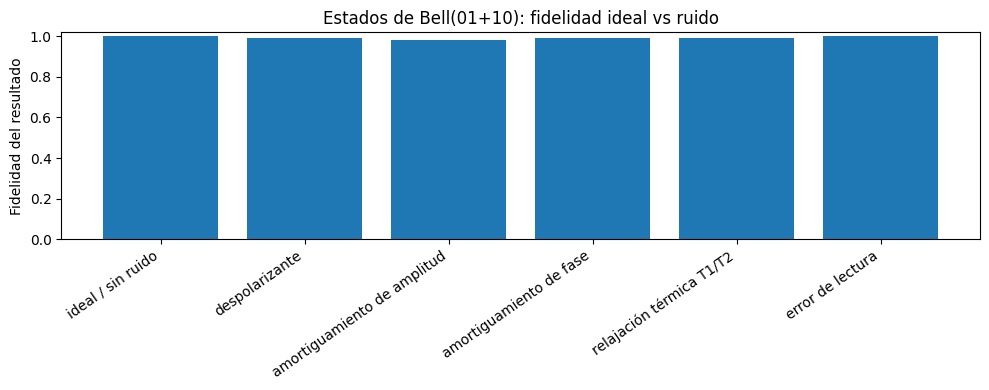

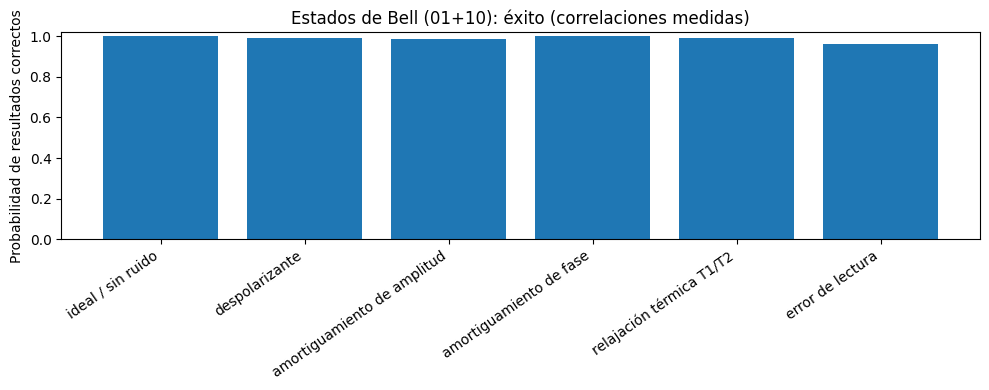

In [8]:
labels = [r[0] for r in rows]
fidelities = [r[1] for r in rows]
successes = [r[2] for r in rows]

plt.figure(figsize=(10, 4))
plt.bar(labels, fidelities)
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.02)
plt.ylabel("Fidelidad del resultado")
plt.title("Estados de Bell(01+10): fidelidad ideal vs ruido")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(labels, successes)
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.02)
plt.ylabel("Probabilidad de resultados correctos")
plt.title("Estados de Bell (01+10): éxito (correlaciones medidas)")
plt.tight_layout()
plt.show()


## 8. Histogramas

Lo que nos importa para Bob es el bit de `q2`, que aparece a la izquierda.


In [9]:
for name in [
    "ideal / sin ruido",
    "despolarizante",
    "amortiguamiento de amplitud",
    "amortiguamiento de fase",
    "relajación térmica T1/T2",
    "error de lectura",
]:
    print(name)
    print(all_counts[name])
    plot_histogram(all_counts[name], title=name)
    plt.show()


ideal / sin ruido
{'10': 2111, '01': 1985}
despolarizante
{'11': 11, '01': 1984, '00': 12, '10': 2089}
amortiguamiento de amplitud
{'11': 17, '00': 37, '10': 2084, '01': 1958}
amortiguamiento de fase
{'10': 2118, '01': 1978}
relajación térmica T1/T2
{'11': 12, '01': 1956, '00': 12, '10': 2116}
error de lectura
{'01': 1962, '11': 75, '00': 79, '10': 1980}


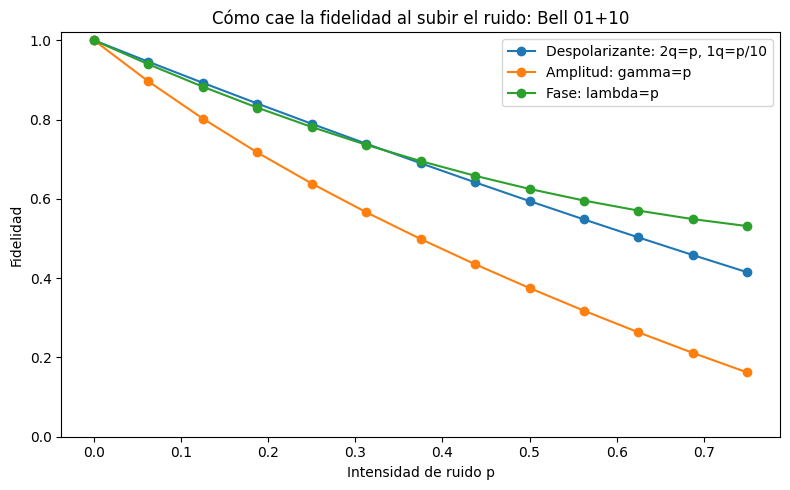

In [10]:
ps = np.linspace(0, 0.75, 13)

scan_dep = []
scan_amp = []
scan_phase = []

for p in ps:
    scan_dep.append(bell_fidelity(depolarizing_noise(p1=p / 10, p2=p)))
    scan_amp.append(bell_fidelity(amplitude_damping_noise(gamma=p)))
    scan_phase.append(bell_fidelity(phase_damping_noise(lam=p)))

plt.figure(figsize=(8, 5))
plt.plot(ps, scan_dep, marker="o", label="Despolarizante: 2q=p, 1q=p/10")
plt.plot(ps, scan_amp, marker="o", label="Amplitud: gamma=p")
plt.plot(ps, scan_phase, marker="o", label="Fase: lambda=p")
plt.xlabel("Intensidad de ruido p")
plt.ylabel("Fidelidad")
plt.ylim(0, 1.02)
plt.title("Cómo cae la fidelidad al subir el ruido: Bell 01+10")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Mini plantilla para aplicar ruido


```python
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 1), ["h", "x", "sx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 2), ["cx"])

backend = AerSimulator(noise_model=noise_model)
tqc = transpile(circuito, backend)
result = backend.run(tqc, shots=4096).result()
```
